In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../..', 'src'))
sys.path.insert(0, src_dir)

from model import WRCircuit
num_exc_neurons = (5, 5)
num_inh_neurons = np.prod(num_exc_neurons)//4
FNSnet = WRCircuit(num_exc_neurons, num_inh_neurons)

/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an

In [2]:
FNSnet.E.embedding.to_dict()
FNSnet.I.embedding.to_dict()
FNSnet.E.to_dict()
FNSnet.I.to_dict()

{'C': 0.25,
 'g_L': 16.7,
 'V_L': -70.0,
 'V_K': -85.0,
 'V_th': -50.0,
 'V_rt': -60.0,
 'tau_ref': 4.0,
 'tau_K': 80.0,
 'Delta_g_K': 10.0,
 'embedding': {'RandomPositions': {'domain': (5, 5)}},
 '_V_initializer': {'Uniform': {'min_val': -70.0, 'max_val': -50.0}},
 '_g_K_initializer': 'ZeroInit'}

In [3]:
FNSnet.E2E.to_dict()

{'delay': 2.0, 'J': 1.0, 'tau_d': 5, 'tau_r': 1, 'V_rev': 0.0, 'alpha': 1.0}

In [4]:
d = FNSnet.to_dict()
d

{'WRCircuit': {'populations': {'E': {'C': 0.25,
    'g_L': 16.7,
    'V_L': -70.0,
    'V_K': -85.0,
    'V_th': -50.0,
    'V_rt': -60.0,
    'tau_ref': 4.0,
    'tau_K': 80.0,
    'Delta_g_K': 10.0,
    'embedding': {'GridPositions': {'domain': (5, 5)}},
    '_V_initializer': {'Uniform': {'min_val': -70.0, 'max_val': -50.0}},
    '_g_K_initializer': 'ZeroInit'},
   'I': {'C': 0.25,
    'g_L': 16.7,
    'V_L': -70.0,
    'V_K': -85.0,
    'V_th': -50.0,
    'V_rt': -60.0,
    'tau_ref': 4.0,
    'tau_K': 80.0,
    'Delta_g_K': 10.0,
    'embedding': {'RandomPositions': {'domain': (5, 5)}},
    '_V_initializer': {'Uniform': {'min_val': -70.0, 'max_val': -50.0}},
    '_g_K_initializer': 'ZeroInit'}},
  'synapses': {'E2E': {'delay': 2.0,
    'J': 1.0,
    'tau_d': 5,
    'tau_r': 1,
    'V_rev': 0.0,
    'alpha': 1.0},
   'E2I': {'delay': 2.0,
    'J': 1.0,
    'tau_d': 5,
    'tau_r': 1,
    'V_rev': 0.0,
    'alpha': 1.0},
   'I2E': {'delay': 2.0,
    'J': 1.0,
    'tau_d': 5,
    'tau

/tmp/ipykernel_321370/1063330246.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


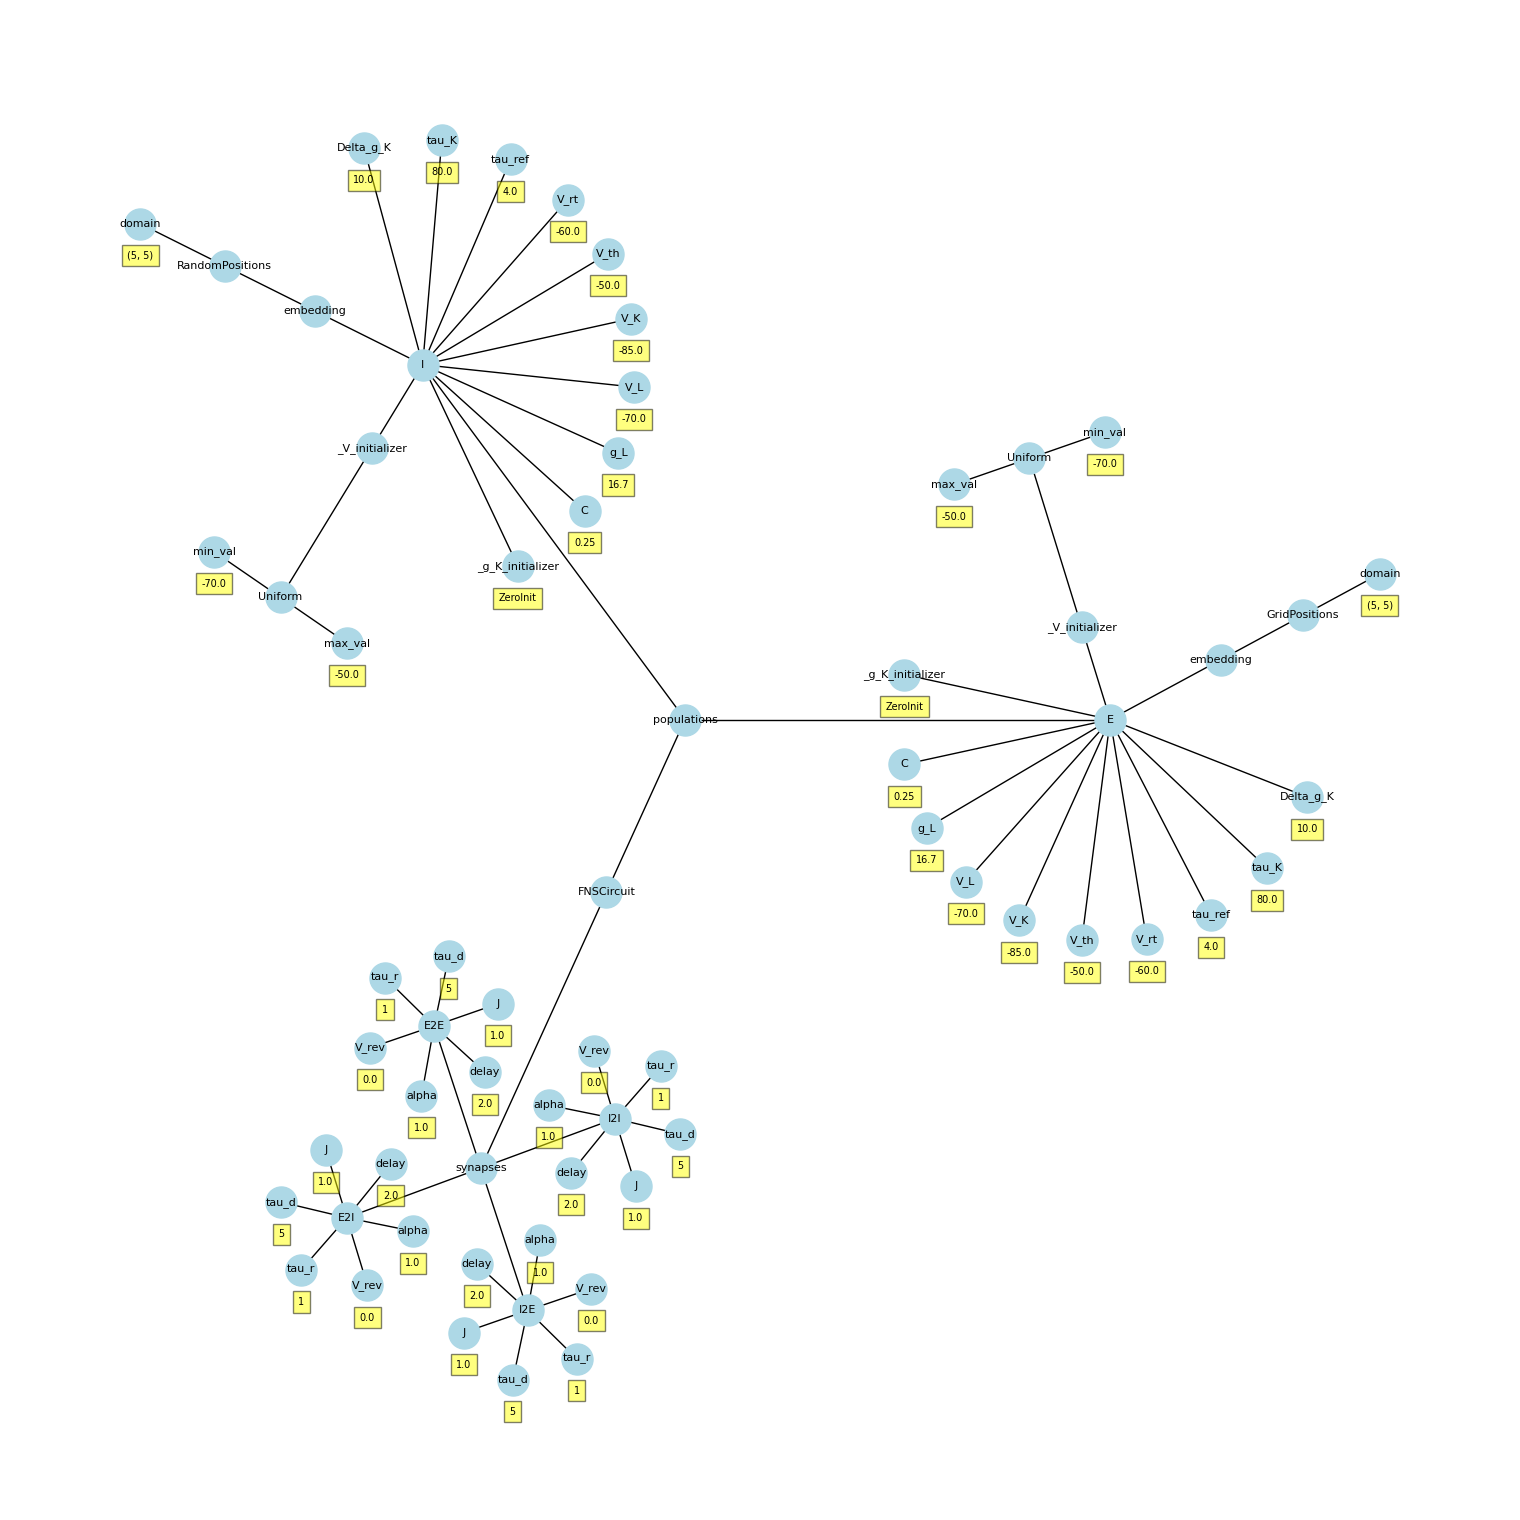

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize a directed graph
G = nx.DiGraph()

# Global node counter for unique node IDs
node_counter = 0

def add_nodes_edges(d, G, parent=None):
    """
    Recursively adds nodes and edges to the graph based on the dictionary structure.
    """
    global node_counter
    for key, value in d.items():
        node_id = node_counter
        node_counter += 1
        G.add_node(node_id, label=key)  # Add node with key as label

        if parent is not None:
            G.add_edge(parent, node_id)  # Add edge from parent to current node

        if isinstance(value, dict):
            # If value is a dictionary, recurse
            add_nodes_edges(value, G, parent=node_id)
        else:
            # If value is a leaf node, store the value in node attributes
            G.nodes[node_id]['value'] = value

# Build the graph starting from the root
add_nodes_edges(d, G)

# Create a mapping of node IDs to labels
labels = {node: G.nodes[node]['label'] for node in G.nodes()}

# Try to use a hierarchical layout; fall back to spring layout if not available
# try:
pos = nx.nx_pydot.graphviz_layout(G, prog="circo", root=1)
# except:
#     pos = nx.spring_layout(G)

# Draw the nodes and edges
plt.figure(figsize=(15, 15))
nx.draw(G, pos, with_labels=False, arrows=False, node_size=500, node_color='lightblue')

# Draw node labels (keys)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

# Annotate leaf nodes with their values
for node in G.nodes():
    if 'value' in G.nodes[node]:
        x, y = pos[node]
        value = G.nodes[node]['value']
        # Adjust the position to place the value adjacent to the node
        plt.text(x, y-50, s=str(value), fontsize=7, ha='center', va='top', bbox=dict(facecolor='yellow', alpha=0.5))

# Display the graph
plt.tight_layout()
plt.show()


In [6]:
import brainpy.math as bm
class EINet(bp.DynSysGroup):
  def __init__(self):
    super().__init__()
    ne, ni = 3200, 800
    delay = bp.init.Uniform(0.0, 4.0)
    self.E = bp.dyn.LifRef(ne, V_rest=-60., V_th=-50., V_reset=-60., tau=20., tau_ref=5.,
                           V_initializer=bp.init.Normal(-55., 2.))
    self.I = bp.dyn.LifRef(ni, V_rest=-60., V_th=-50., V_reset=-60., tau=20., tau_ref=5.,
                           V_initializer=bp.init.Normal(-55., 2.))
    self.E2E = bp.dyn.FullProjAlignPreDSMg(pre=self.E,
                                          delay=delay,
                                          syn=bp.dyn.Expon.desc(size=ne, tau=5.),
                                          comm=bp.dnn.JitFPHomoLinear(ne, ne, prob=0.02, weight=0.6),
                                          out=bp.dyn.COBA(E=0.),
                                          post=self.E)
    self.E2I = bp.dyn.FullProjAlignPreDSMg(pre=self.E,
                                          delay=2.0,
                                          syn=bp.dyn.Expon.desc(size=ne, tau=5.),
                                          comm=bp.dnn.JitFPHomoLinear(ne, ni, prob=0.02, weight=0.6),
                                          out=bp.dyn.COBA(E=0.),
                                          post=self.I)
    self.I2E = bp.dyn.FullProjAlignPreDSMg(pre=self.I,
                                          delay=2.0,
                                          syn=bp.dyn.Expon.desc(size=ni, tau=10.),
                                          comm=bp.dnn.JitFPHomoLinear(ni, ne, prob=0.02, weight=6.7),
                                          out=bp.dyn.COBA(E=-80.),
                                          post=self.E)
    self.I2I = bp.dyn.FullProjAlignPreDSMg(pre=self.I,
                                          delay=2.0,
                                          syn=bp.dyn.Expon.desc(size=ni, tau=10.),
                                          comm=bp.dnn.JitFPHomoLinear(ni, ni, prob=0.02, weight=6.7),
                                          out=bp.dyn.COBA(E=-80.),
                                          post=self.I)

  def update(self, inp):
    self.E2E()
    self.E2I()
    self.I2E()
    self.I2I()
    self.E(inp)
    self.I(inp)
    return self.E.spike

model = EINet()
indices = bm.arange(1000)
spks = bm.for_loop(lambda i: model.step_run(i, 20.), indices)
bp.visualize.raster_plot(indices, spks, show=True)


AssertionError: 

brainpy._src.delay.VarDelay